In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
# Importing Libraries

In [3]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
!nvidia-smi

Mon Jun 15 14:35:30 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 610.47                 KMD Version: 610.47        CUDA UMD Version: 13.3     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce GTX 1650      WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   52C    P8              6W /   30W |       0MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
# Data Preprocessing
#Training Image Preprocessing
training_set = tf.keras.utils.image_dataset_from_directory(
    'train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 70295 files belonging to 38 classes.


In [6]:
## Validation Image Preprocessing

validation_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)


Found 17572 files belonging to 38 classes.


In [7]:
training_set

<BatchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

In [8]:
for x,y in training_set:
    print(x,x.shape)
    print(y,y.shape)
    break

tf.Tensor(
[[[[ 88.75  91.75 100.75]
   [ 86.5   89.5   98.5 ]
   [ 87.5   90.5   99.5 ]
   ...
   [183.25 173.25 172.25]
   [164.75 154.75 153.75]
   [166.75 156.75 155.75]]

  [[ 90.75  93.75 102.75]
   [ 89.    92.   101.  ]
   [ 90.75  93.75 102.75]
   ...
   [167.   157.   156.  ]
   [187.5  177.5  176.5 ]
   [173.75 163.75 162.75]]

  [[ 89.25  92.25 101.25]
   [ 87.75  90.75  99.75]
   [ 90.5   93.5  102.5 ]
   ...
   [157.   147.   146.  ]
   [178.   168.   167.  ]
   [165.   155.   154.  ]]

  ...

  [[156.25 148.25 146.25]
   [156.5  148.5  146.5 ]
   [155.   147.   145.  ]
   ...
   [131.   120.   116.  ]
   [130.75 119.75 115.75]
   [140.   129.   125.  ]]

  [[154.75 146.75 144.75]
   [153.5  145.5  143.5 ]
   [153.   145.   143.  ]
   ...
   [135.25 124.25 120.25]
   [123.25 112.25 108.25]
   [126.75 115.75 111.75]]

  [[151.5  143.5  141.5 ]
   [150.5  142.5  140.5 ]
   [152.75 144.75 142.75]
   ...
   [134.   123.   119.  ]
   [126.5  115.5  111.5 ]
   [133.25 122.25 11

In [9]:
### To avoid Overshooting

    #Choose small learning rate default 0.001 we are taking 0.0001
   # There may be chance of Underfitting, so increase number of neuron
    #Add more Convolution layer to extract more feature from images there may #be possibilty that model unable to capture relevant feature or model is #confusing due to lack of feature so feed with more feature


In [10]:
cnn = tf.keras.models.Sequential()

In [11]:

# Building Convolution Layer
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,padding='same',activation='relu',input_shape=[128,128,3]))
cnn.add(tf.keras.layers.Conv2D(filters=32,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))



In [12]:


cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=64,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))



In [13]:

cnn.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=128,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [14]:
cnn.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=256,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [15]:
cnn.add(tf.keras.layers.Conv2D(filters=512,kernel_size=3,padding='same',activation='relu'))
cnn.add(tf.keras.layers.Conv2D(filters=512,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

In [16]:
cnn.add(tf.keras.layers.Dropout(0.25)) # To avoid Overfitting

In [17]:
cnn.add(tf.keras.layers.Flatten())

In [18]:
cnn.add(tf.keras.layers.Dense(units=1500,activation='relu'))

In [19]:
cnn.add(tf.keras.layers.Dropout(0.4)) #To avoid overfitting

In [20]:
#Output Layer
cnn.add(tf.keras.layers.Dense(units=38,activation='softmax'))

In [21]:
### Compiling Model
cnn.compile(optimizer=tf.keras.optimizers.legacy.Adam(
    learning_rate=0.0001),loss='categorical_crossentropy',metrics=['accuracy'])

In [22]:
cnn.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 conv2d_1 (Conv2D)           (None, 126, 126, 32)      9248      
                                                                 
 max_pooling2d (MaxPooling2D  (None, 63, 63, 32)       0         
 )                                                               
                                                                 
 conv2d_2 (Conv2D)           (None, 63, 63, 64)        18496     
                                                                 
 conv2d_3 (Conv2D)           (None, 61, 61, 64)        36928     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 30, 30, 64)       0         
 2D)                                                    

In [23]:
###  Model Training
training_history = cnn.fit(x=training_set,validation_data=validation_set,epochs=10)

Epoch 1/10


2197/2197 [==============================] - 267s 115ms/step - loss: 1.3670 - accuracy: 0.5977 - val_loss: 0.5090 - val_accuracy: 0.8424
Epoch 2/10
2197/2197 [==============================] - 207s 94ms/step - loss: 0.4575 - accuracy: 0.8555 - val_loss: 0.3931 - val_accuracy: 0.8712
Epoch 3/10
2197/2197 [==============================] - 208s 95ms/step - loss: 0.2815 - accuracy: 0.9090 - val_loss: 0.2040 - val_accuracy: 0.9351
Epoch 4/10
2197/2197 [==============================] - 205s 93ms/step - loss: 0.1899 - accuracy: 0.9383 - val_loss: 0.1559 - val_accuracy: 0.9490
Epoch 5/10
2197/2197 [==============================] - 205s 93ms/step - loss: 0.1417 - accuracy: 0.9532 - val_loss: 0.1386 - val_accuracy: 0.9563
Epoch 6/10
2197/2197 [==============================] - 205s 93ms/step - loss: 0.1123 - accuracy: 0.9638 - val_loss: 0.1437 - val_accuracy: 0.9568
Epoch 7/10
2197/2197 [==============================] - 206s 94ms/step - loss: 0.0905 - accuracy: 0.9704 - val_loss: 0.1098 - va

In [24]:
#Training set Accuracy
#Model Evaluation on Training set

train_loss, train_acc = cnn.evaluate(training_set)
print('Training accuracy:', train_acc)

2197/2197 [==============================] - 72s 33ms/step - loss: 0.0227 - accuracy: 0.9932
Training accuracy: 0.9931573867797852


In [25]:
#Validation set Accuracy
val_loss, val_acc = cnn.evaluate(validation_set)
print('Validation accuracy:', val_acc)

550/550 [==============================] - 18s 32ms/step - loss: 0.1079 - accuracy: 0.9664
Validation accuracy: 0.9664238691329956


In [26]:
# Saving Model
cnn.save('trained_plant_disease_model.keras')

In [27]:
training_history.history #Return Dictionary of history

{'loss': [1.3670376539230347,
  0.4574907422065735,
  0.2814689874649048,
  0.18990644812583923,
  0.14173735678195953,
  0.11232618242502213,
  0.09045622497797012,
  0.07780776172876358,
  0.06502322852611542,
  0.05900466442108154],
 'accuracy': [0.5976812243461609,
  0.8555231690406799,
  0.9089977741241455,
  0.9383028745651245,
  0.9531545639038086,
  0.9637954235076904,
  0.9703534841537476,
  0.9740380048751831,
  0.9785902500152588,
  0.9807810187339783],
 'val_loss': [0.5089653730392456,
  0.3931330144405365,
  0.20396092534065247,
  0.1558944433927536,
  0.13860972225666046,
  0.14372657239437103,
  0.10978648066520691,
  0.09860162436962128,
  0.11700717359781265,
  0.10789744555950165],
 'val_accuracy': [0.8424197435379028,
  0.8712155818939209,
  0.9350671768188477,
  0.9490097761154175,
  0.9562941193580627,
  0.9568063020706177,
  0.9630662202835083,
  0.9692124128341675,
  0.9628955125808716,
  0.9664238691329956]}

In [28]:
#Recording History in json
import json
with open('training_hist.json','w') as f:
  json.dump(training_history.history,f)

In [29]:
training_history.history['val_accuracy']

[0.8424197435379028,
 0.8712155818939209,
 0.9350671768188477,
 0.9490097761154175,
 0.9562941193580627,
 0.9568063020706177,
 0.9630662202835083,
 0.9692124128341675,
 0.9628955125808716,
 0.9664238691329956]

In [30]:
print(training_history.history.keys())

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])


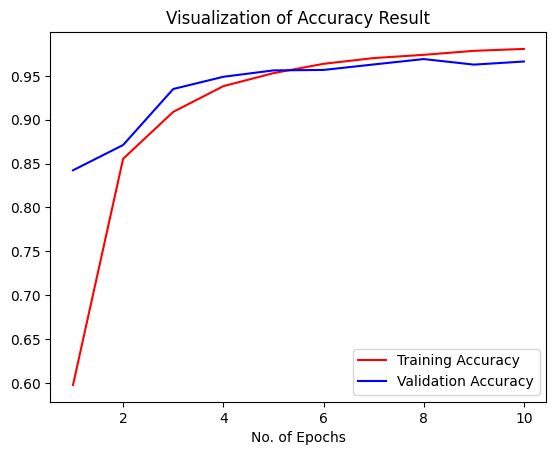

In [31]:
## Accuracy Visualization
epochs = [i for i in range(1,11)]
plt.plot(epochs,training_history.history['accuracy'],color='red',label='Training Accuracy')
plt.plot(epochs,training_history.history['val_accuracy'],color='blue',label='Validation Accuracy')
plt.xlabel('No. of Epochs')
plt.title('Visualization of Accuracy Result')
plt.legend()
plt.show()

In [32]:
### Some other metrics for model evaluation
class_name = validation_set.class_names

In [34]:
test_set = tf.keras.utils.image_dataset_from_directory(
    'valid',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=1,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 17572 files belonging to 38 classes.


In [35]:
y_pred = cnn.predict(test_set)
predicted_categories = tf.argmax(y_pred, axis=1)

17572/17572 [==============================] - 64s 4ms/step


In [36]:
true_categories = tf.concat([y for x, y in test_set], axis=0)
true_categories



<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [37]:
Y_true = tf.argmax(true_categories, axis=1)
Y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], dtype=int64)>

In [38]:
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], dtype=int64)>

In [39]:
from sklearn.metrics import confusion_matrix,classification_report
cm = confusion_matrix(Y_true,predicted_categories)

In [40]:
# Precision Recall Fscore
print(classification_report(Y_true,predicted_categories,target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.99      0.92      0.95       504
                                 Apple___Black_rot       0.99      0.99      0.99       497
                          Apple___Cedar_apple_rust       0.95      1.00      0.97       440
                                   Apple___healthy       0.97      0.92      0.94       502
                               Blueberry___healthy       0.96      0.96      0.96       454
          Cherry_(including_sour)___Powdery_mildew       1.00      0.97      0.98       421
                 Cherry_(including_sour)___healthy       0.98      0.99      0.98       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.92      0.94      0.93       410
                       Corn_(maize)___Common_rust_       1.00      0.98      0.99       477
               Corn_(maize)___Northern_Leaf_Blight       0.97      0.95      0.

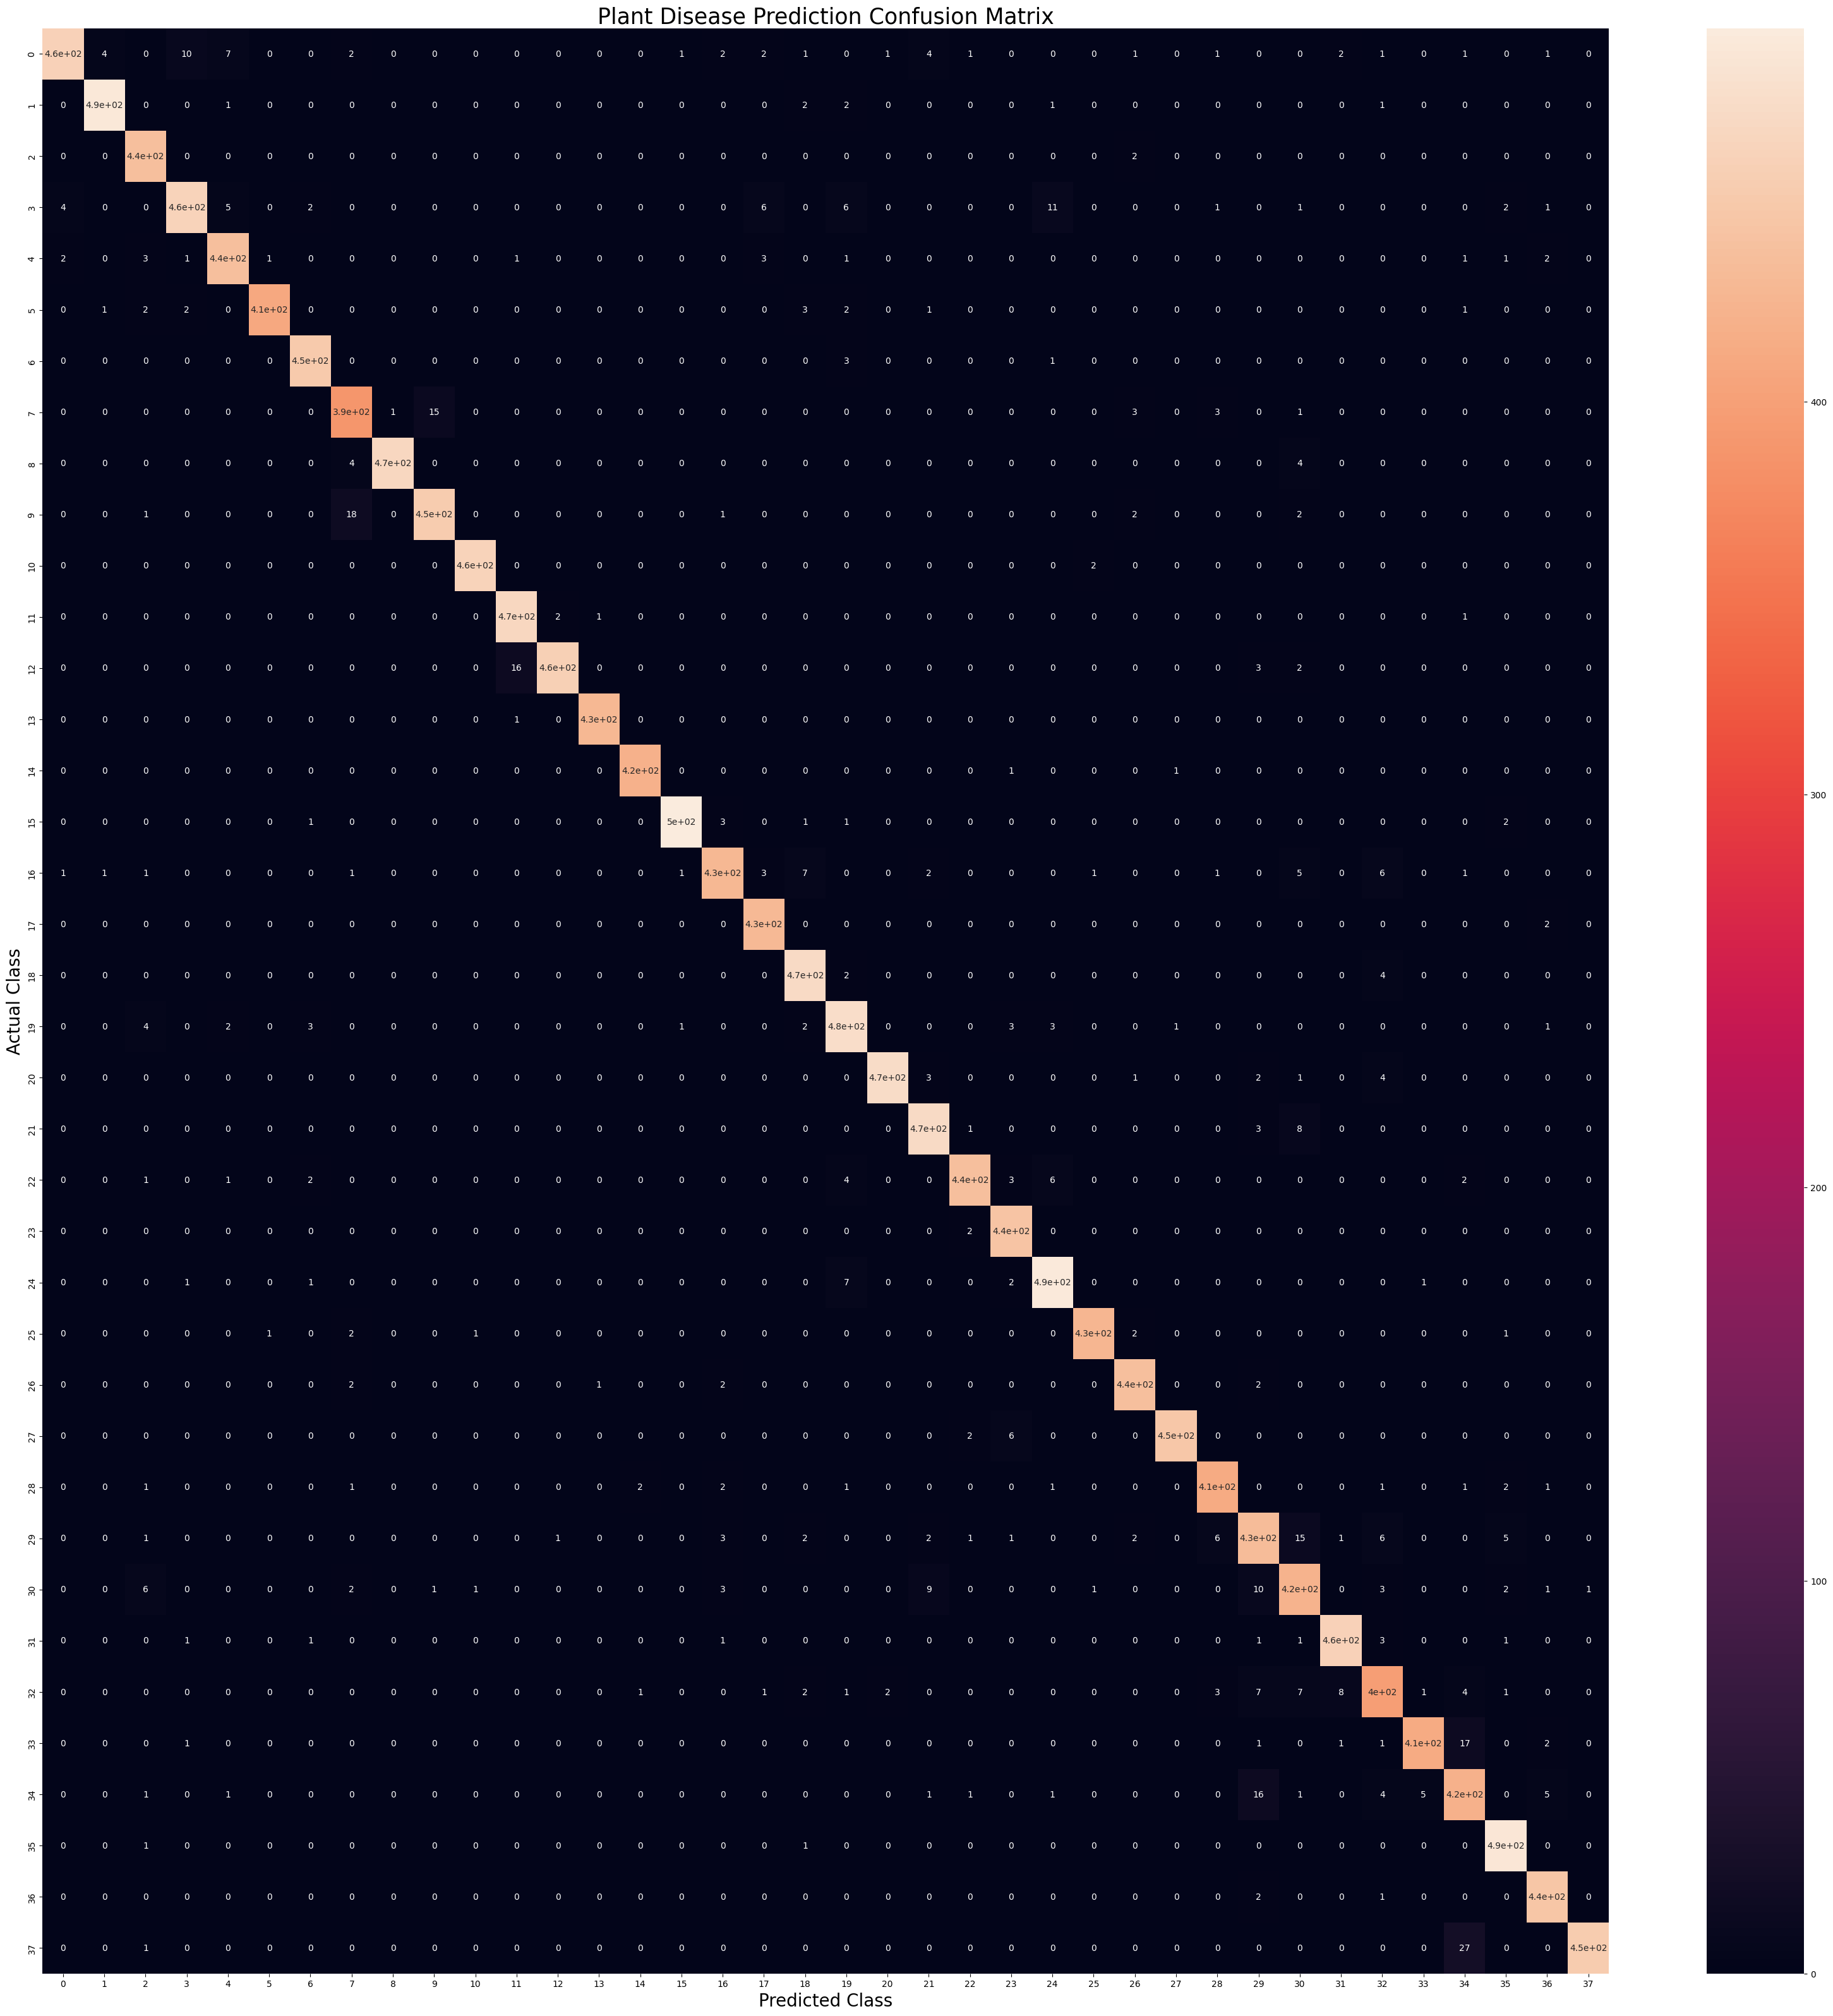

In [41]:
plt.figure(figsize=(40, 40))
sns.heatmap(cm,annot=True,annot_kws={"size": 10})

plt.xlabel('Predicted Class',fontsize = 20)
plt.ylabel('Actual Class',fontsize = 20)
plt.title('Plant Disease Prediction Confusion Matrix',fontsize = 25)
plt.show()

In [ ]:
from PIL import Image
import os

bad_files = []

for root, dirs, files in os.walk("train"):
    for file in files:
        path = os.path.join(root, file)

        try:
            img = Image.open(path)
            img.verify()
        except Exception as e:
            bad_files.append((path, str(e)))

print("Bad files found:", len(bad_files))

for file, error in bad_files[:20]:
    print(file)
    print(error)
    print("-"*50)

Bad files found: 1
train\.DS_Store
cannot identify image file 'train\\.DS_Store'
--------------------------------------------------
